## **Retrieval Extraction with Embeddings and Cosine Similarity (Without Augmentation & Without Generation)**

Retrieval: Retrieve the most relevant passage or context based on the input question using embeddings and cosine similarity.

Extraction: Extracting the most relevant answer based on embeddings and cosine similarity, without any augmentation or generation steps.

Result: The answer is extracted directly from the context provided by the retrieved passage. The answer is simply the most relevant passage based on similarity.There is no generative model involved.

## Embeddings using 'all-'MiniLM'-v2' and 'Ollama'

**all-MiniLM-L6-v2**: A lightweight, transformer-based model for generating efficient and high-quality sentence embeddings, good for general-purpose NLP tasks.

**Ollama Embeddings**: A specialized embedding that  provide customized or optimized embeddings for specific applications, often with a focus on specific industries or use cases.s

In [1]:
!pip install -qqq ollama
!pip install -qqq langchain faiss-cpu python-dotenv
!pip install -qqq -U langchain-openai
!pip install -qqq langchain-core langchain-openai langchain-community
!pip install -qqq matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.2/65.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.1/438.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.9 MB/s eta 0:00:00


In [ ]:
import os
print(os.getcwd())

/content


In [2]:
import requests
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from transformers import pipeline, AutoModel, AutoTokenizer
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
import ollama
import torch
from langchain_community.embeddings import OllamaEmbeddings
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Ensure the directory exists
#os.makedirs('./data/', exist_ok=True)

In [5]:
import subprocess
import json
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import DistilBertForQuestionAnswering, DistilBertTokenizer
from transformers import BartTokenizer, BartForConditionalGeneration

In [6]:
# Load the summary from the file
def load_summary(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        return file.read()

# Main execution
summary_file_path = './msc_ai_hullonline_short.txt'
loaded_summary = load_summary(summary_file_path)

# Print the loaded summary
print(loaded_summary)

The MSc Artificial Intelligence Online is delivered 100% online.
The MSc Artificial Intelligence Online program takes two years to complete on a part-time basis.
The total cost of the the MSc Artificial Intelligence (AI) Online program is £8,950, with instalment and funding options available.
The start dates for the for the MSc Artificial Intelligence Online program are in January, May, and September.
Yes, the 30-week PGCert in Responsible Artificial Intelligence is available for those seeking a shorter course.
The Programme Director for the MSc in Artificial Intelligence Online at the University of Hull is Dr. Rameez Kureshi.
The PGCert Artificial Intelligence program takes 30 weeks to complete on a part-time basis.
The total cost of the PGCert in Artificial Intelligence is £2,750.
The minimum academic qualification required to apply for the MSc Artificial Intelligence Online program is an Honours degree at 2:2 or above (or international equivalent) in a STEM discipline or a closely r

##### The distilbert-base-cased-distilled-squad model is a question-answering model, not a sentence-transformers model, which is required for generating embeddings.

## Define Questions

In [7]:
questions = [
    "What is the mode of delivery for the MSc Artificial Intelligence Online?",
    "How long does the MSc Artificial Intelligence course take to complete?",
    "What is the total cost of the MSc Artificial Intelligence Online program?",
    "When are the start dates for the MSc Artificial Intelligence Online program?",
    "Is there a shorter AI course available besides the MSc Artificial Intelligence Online?",
    "Who is the Programme Director for the MSc in Artificial Intelligence Online at the University of Hull?",
    "How long does the PGCert in Artificial Intelligence take to complete?",
    "What is the total cost of the PGCert in Artificial Intelligence?",
    "What is the minimum academic qualification required to apply for the MSc Artificial Intelligence (Online) program?",
    "What if I don't have a degree but have relevant professional experience?",
    "What language proficiency is required if my first language isn't English?",
    "Who are the lecturers for the MSc Artificial Intelligence program at the University of Hull?",
    "What are the payment options available for tuition at the University of Hull online?",
    "How can I pay my tuition online?",
    "How do I arrange to pay by bank transfer?",
    "What is the WhatsApp number to reach the course advisers at the University of Hull?",
    "When should self-funding students make their tuition payments?",
    "What is the payment deadline for students using student loans?",
    "Where are the students at the University of Hull from?",
    "What kind of community can I expect as an online student at the University of Hull?",
    "What will my student status be once accepted onto an online Masters course at the University of Hull?",
    "Will I receive a University of Hull student ID card as an online student?",
    "What will be on my degree certificate after completing an online Masters course at the University of Hull?",
    "Is there a graduation ceremony for online students at the University of Hull?",
    "What is the phone number to reach the course advisers at the University of Hull?",
    "What is the email address for enquiries about online courses at the University of Hull?",
    "What are the payment options available for paying tuition fees at the University of Hull Online?",
    "Is there any discount available for referring a friend to the University of Hull Online?",
    "What is the total course fee for the MSc in Healthcare Leadership?",
    "How much does the MA in Creative Writing cost?",
    "What is the tuition fee for the PGDip in Healthcare Leadership?",
    "What is the cost of the MSc in Dementia program?",
    "How much does the PGCert in Healthcare Leadership cost?",
    "What is the fee for the PGDip in Dementia?",
    "How much does the MSc in Logistics and Supply Chain Management cost?",
    "What is the tuition fee for the PGCert in Dementia?",
    "What is the total cost of the MSc in People Analytics program?",
    "How much does the MSc in Digital Transformation cost?",
    "What is the fee for the PG Award in People Analytics?",
    "What is the cost of the MA in Education program?",
    "How much does the MSc in Engineering Management cost?",
    "How much does the Global MBA program cost?",
    "What is the University of Hull's ranking in the north of the UK according to the Times Good University Guide 2022?",
    "How did the University of Hull perform in the Guardian University Rankings 2022?",
    "What modules will be covered in the MSc Artificial Intelligence course?",
    "How if I don't have money and have financial problem in the University of Hull's MSc Artificial Intelligence online program? Any loan, scholarship, funding, or financial support?",
    "Are there any exams in the University of Hull's MSc Artificial Intelligence online program?",
    "What happens to my tuition fees if I temporarily suspend my studies at the University of Hull Online?",
    "What happens if I have outstanding financial commitments to Hull Online?",
    "Why study a Master's in Artificial Intelligence at University of Hull online?",
]

ground_truth_answers = [
        "The MSc Artificial Intelligence Online is delivered 100% online.",
        "The MSc Artificial Intelligence Online program takes two years to complete on a part-time basis.",
        "The total cost of the the MSc Artificial Intelligence Online program is £8,950, with instalment and funding options available.",
        "The start dates for the for the MSc Artificial Intelligence Online program are in January, May, and September.",
        "Yes, the 30-week PGCert in Responsible Artificial Intelligence is available for those seeking a shorter course.",
        "The Programme Director for the MSc in Artificial Intelligence Online at the University of Hull is Dr. Rameez Kureshi.",
        "The PGCert Artificial Intelligence program takes 30 weeks to complete on a part-time basis.",
        "The total cost of the PGCert in Artificial Intelligence is £2,750.",
        "The minimum academic qualification required to apply for the MSc Artificial Intelligence Online program is an Honours degree at 2:2 or above (or international equivalent) in a STEM discipline or a closely related subject.",
        "Applicants without relevant degree qualifications will be considered based on relevant professional experience or training, including competence in computer programming.",
        "An IELTS score of 6.0 (with a minimum of 5.5 in each skill) or an equivalent English language proficiency qualification is required.",
        "The lecturers for the MSc Artificial Intelligence program at the University of Hull are Dr. Rameez Kureshi, Professor Adil Khan, Khadija Fraz, Dr. Bhupesh Mishra, Professor Dhaval Thakker",
        "You can pay for tuition online, over the phone using a credit or debit card, or by bank transfer.",
        "To pay online, visit the Convera GlobalPay website after receiving your offer.",
        "To arrange payment by bank transfer, email finance-online@hull.ac.uk after receiving your offer.",
        "You can reach the course advisers at the University of Hull by WhatsApp at  +44 (0)7360 538906",
        "Self-funding students should make the first payment no later than four weeks before the course start date, with subsequent payments due four weeks before each term.",
        "Students using loans must pay their first instalment no later than two weeks after receiving the first loan payment, with subsequent payments due two weeks after each loan payment.",
        "At the University of Hull, students come from over 100 countries around the world, making it a truly global community.",
        "As an online student, you will study alongside peers from across the world and become part of the University's global community.",
        "Once accepted onto an online Masters course, you will be welcomed as a fully-registered student with the University of Hull.",
        "Yes, as a fully-registered student, you will be eligible for a University of Hull student ID card.",
        "Your degree certificate will have the exact same academic weight as that of an on-campus student, with no distinction made between online and on-campus study.",
        "Yes, you will be invited to a graduation ceremony at Hull to celebrate your achievement and receive your degree certificate, identical to that of an on-campus student.",
        "You can reach the course advisers at the University of Hull by phone at +44(0)1482 251 819.",
        "The email address for enquiries about online courses at the University of Hull is enquiries-online@hull.ac.uk.",
        "For the payment options, you can choose to pay fees in full before starting your course or in six convenient instalments over the duration of the course.",
        "Student who refers another student to the University of Hull Online is eligible for a tuition fee discount of up to £750.",
        "The total course fee for the MSc in Healthcare Leadership is £9,950.",
        "The MA in Creative Writing costs £10,600.",
        "The tuition fee for the PGDip in Healthcare Leadership is £6,700.",
        "The cost of the MSc in Dementia program is £10,600.",
        "The PGCert in Healthcare Leadership costs £3,400.",
        "The fee for the PGDip in Dementia is £7,100.",
        "The MSc in Logistics and Supply Chain Management costs £9,950.",
        "The tuition fee for the PGCert in Dementia is £3,600.",
        "The total cost of the MSc in People Analytics program is £10,600.",
        "The MSc in Digital Transformation costs £10,600.",
        "The fee for the PG Award in People Analytics is £1,800.",
        "The cost of the MA in Education program is £8,950.",
        "The MSc in Engineering Management costs £8,950.",
        "The Global MBA program costs £12,150.",
        "The University of Hull is ranked 4th in the north of the UK according to the Times Good University Guide 2022.",
        "The University of Hull climbed 19 places in the Guardian University Rankings 2022.",
        "The MSc Artificial Intelligence course covers the following modules: AI Foundations, Machine Learning & Deep Learning, Ethical Regulatory and Social Aspects for Fair AI, Applied AI, Research/Consultancy Project",
        "If you're experiencing financial or money difficulties, as a University of Hull Online student, you may be eligible for various funding options and bursaries to help cover your course fees. For more information about loans, bursaries, or fee reductions, please call +44(0)1482 251 819 or email enquiries-online@hull.ac.uk.",
        "There are no exams in the University of Hull's MSc Artificial Intelligence online program. All assessments are based on coursework, which is submitted online.",
        "If you temporarily suspend your studies, any tuition fees already paid will be retained until you resume or permanently withdraw. You may be charged again for retaking modules and remain liable for any outstanding fees.",
        "If you have outstanding financial commitments to Hull Online, you won't be able to progress to your next module until your debt is repaid or alternative arrangements are made. To dispute a debt, email finance-online@hull.ac.uk within 7 days of receiving a payment demand.",
        "AI is one of the disruptive innovations of this century that influences all aspects of industries. Our online, part-time MSc in Artificial Intelligence will help you get there. Study from anywhere in the world, at times that suit you best, with expert guidance from our academics and support staff.",
]

## A. Retrieval Extraction with 'all-'MiniLM'-v2' Embeddings and Cosine Similarity:

all-MiniLM-L6-v2' is a lightweight version of a transformer model designed for generating sentence embeddings, based on the architecture of transformer models like BERT, RoBERTa, DistilBERT.

"MiniLM" in the model name refers to Microsoft's MiniLM (Miniature Language Model).

**1. Embedding Process**:
The model all-MiniLM-L6-v2 is used to generate sentence embeddings for both the questions and the corresponding answers.
The embeddings are created using the SentenceTransformer class, and cosine similarity is computed between the question embedding and all answer embeddings.

**2.Retrieval Process**:

For each question, the code computes cosine similarity between the question's embedding and each answer's embedding.
The answer with the highest cosine similarity score is selected as the most relevant (retrieved) answer.

**3. Evaluation**:

*Exact Match (EM) Score*: This is calculated by comparing each retrieved answer to the ground truth answer. If they match exactly, it's considered a correct match.

*F1 Score*: This score measures the overlap between the tokens in the retrieved answer and the ground truth answer, considering both precision (how much of the retrieved answer is relevant) and recall (how much of the relevant answer was retrieved).

**4.Visualization**:

The resulting EM and F1 scores are visualized using a bar chart.

### A1. Embedding Process

In [9]:
# Ensure the directory exists
# os.makedirs('./data/', exist_ok=True)

# Function to generate embeddings, find the most relevant answers, and save them
def perform_embeddings(embedding_model_name, questions, answers):
    # Load the embedding model
    model = SentenceTransformer(embedding_model_name)

    # Generate embeddings for the answers
    answer_embeddings = model.encode(answers, convert_to_tensor=True)

    predictions = []

    for question in questions:
        # Generate embedding for the question
        question_embedding = model.encode(question, convert_to_tensor=True)

        # Compute cosine similarity between the question and answers
        similarities = util.pytorch_cos_sim(question_embedding, answer_embeddings)

        # Find the index of the most similar answer
        most_similar_index = similarities.argmax()

        # Retrieve the most relevant answer
        most_relevant_answer = answers[most_similar_index]

        predictions.append(most_relevant_answer)

        print(f"Q: {question}\nA: {most_relevant_answer}\n")

    return predictions, answer_embeddings

### A2.Retrieval Process:

In [10]:

# Define the model name
embedding_model_name = "all-MiniLM-L6-v2"

# Perform QA with MiniLM embeddings
predictions, MiniLM_embeddings = perform_embeddings(embedding_model_name, questions, ground_truth_answers)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Q: What is the mode of delivery for the MSc Artificial Intelligence Online?
A: The MSc Artificial Intelligence Online is delivered 100% online.

Q: How long does the MSc Artificial Intelligence course take to complete?
A: The MSc Artificial Intelligence Online program takes two years to complete on a part-time basis.

Q: What is the total cost of the MSc Artificial Intelligence Online program?
A: The total cost of the the MSc Artificial Intelligence Online program is £8,950, with instalment and funding options available.

Q: When are the start dates for the MSc Artificial Intelligence Online program?
A: The start dates for the for the MSc Artificial Intelligence Online program are in January, May, and September.

Q: Is there a shorter AI course available besides the MSc Artificial Intelligence Online?
A: Yes, the 30-week PGCert in Responsible Artificial Intelligence is available for those seeking a shorter course.

Q: Who is the Programme Director for the MSc in Artificial Intelligence

#### Save the "all-MiniLM-L6-v2" embeddings

In [12]:
# Save the embeddings to a file
embedding_file_path = './MiniLM_embeddings.pkl'

with open(embedding_file_path, 'wb') as f:
    pickle.dump(MiniLM_embeddings, f)

print(f"Embeddings saved to {embedding_file_path}")

Embeddings saved to ./MiniLM_embeddings.pkl


#### Load and print the saved "all-MiniLM-L6-v2" embeddings from the file

In [14]:
# Path to the embeddings file
embedding_file_path = './MiniLM_embeddings.pkl'

# Load the embeddings from the file
with open(embedding_file_path, 'rb') as f:
    loaded_embeddings = pickle.load(f)

# Print the loaded embeddings
print(f"Embeddings loaded from {embedding_file_path}:")
print(loaded_embeddings)

Embeddings loaded from ./MiniLM_embeddings.pkl:
tensor([[-0.0085, -0.0413, -0.0224,  ...,  0.0242,  0.0368, -0.0420],
        [ 0.0013, -0.0196,  0.0717,  ...,  0.0050, -0.0168, -0.0241],
        [ 0.0104, -0.0448, -0.0073,  ..., -0.1133,  0.0067, -0.0541],
        ...,
        [-0.0032,  0.0185,  0.0305,  ..., -0.1018, -0.0088, -0.1263],
        [-0.0040, -0.0270, -0.0132,  ..., -0.0637, -0.0187, -0.0260],
        [-0.0126, -0.0409,  0.0487,  ...,  0.0097,  0.0007, -0.0070]])


### A3. Evaluation:

### Calculates the Exact Match (EM) Score and F1 Score for a retrieval-based extraction task using all-MiniLM-L6-v2 embeddings and cosine similarity.

Exact Match (EM) Score: Measures the proportion of exactly matching answers between the retrievals and the ground truths.

F1 Score: Measures the overlap between the retrieved and ground truth answers in terms of shared tokens, balancing precision and recall.

In [15]:
# Function to calculate Exact Match and F1 Score
def evaluate(predictions, ground_truths):
    em_score = sum([1 if pred == truth else 0 for pred, truth in zip(predictions, ground_truths)]) / len(ground_truths)

    f1_scores = []
    for pred, truth in zip(predictions, ground_truths):
        pred_tokens = pred.split()
        truth_tokens = truth.split()
        common_tokens = set(pred_tokens) & set(truth_tokens)
        if len(common_tokens) == 0:
            f1_scores.append(0)
        else:
            precision = len(common_tokens) / len(pred_tokens)
            recall = len(common_tokens) / len(truth_tokens)
            f1 = 2 * (precision * recall) / (precision + recall)
            f1_scores.append(f1)

    f1_score_avg = sum(f1_scores) / len(f1_scores)

    return em_score, f1_score_avg

# Evaluate the predictions
em_score, f1_score_avg = evaluate(predictions, ground_truth_answers)
print(f"Exact Match (EM) Score: {em_score:.2f}")
print(f"F1 Score: {f1_score_avg:.2f}")

Exact Match (EM) Score: 0.88
F1 Score: 0.87


### A4.Visualization:

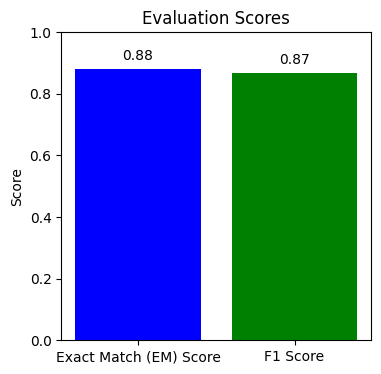

In [16]:
# Visualize the EM and F1 scores using a bar chart
scores = [em_score, f1_score_avg]
score_labels = ['Exact Match (EM) Score', 'F1 Score']

plt.figure(figsize=(4, 4))
bars = plt.bar(score_labels, scores, color=['blue', 'green'])
plt.ylim(0, 1)  # Since scores are between 0 and 1
plt.title('Evaluation Scores')
plt.ylabel('Score')

# Add the score value above each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

plt.show()

## Create Streamlit app

In [17]:
%%writefile requirements.txt

streamlit
sentence-transformers
torch
numpy

Writing requirements.txt


In [19]:
%%writefile RetrievalExtraction_ChatBot.py

import streamlit as st
import os
import pickle
from sentence_transformers import SentenceTransformer, util
import time

# Set page configuration
st.set_page_config(
    page_title="🐣Retrieval-Based Chatbot",
    page_icon="./icon.png",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Add custom CSS for enhanced styling
st.markdown("""
<style>
    .main-header {
        font-size: 2.5rem;
        color: #1E88E5;
        text-align: center;
        margin-bottom: 0.5rem;
    }
    .sub-header {
        font-size: 1.5rem;
        color: #424242;
        text-align: center;
        margin-bottom: 2rem;
    }
    .chat-container {
        background-color: #f8f9fa;
        padding: 1.5rem;
        border-radius: 1rem;
        margin: 1rem 0;
        border-left: 4px solid #1E88E5;
    }
    .question-text {
        font-weight: bold;
        color: #1565C0;
        margin-bottom: 0.5rem;
    }
    .answer-text {
        color: #2E7D32;
        line-height: 1.6;
        background-color: #E8F5E8;
        padding: 1rem;
        border-radius: 0.5rem;
        margin-top: 0.5rem;
    }
    .similarity-score {
        background-color: #E3F2FD;
        padding: 0.5rem;
        border-radius: 0.3rem;
        margin-top: 0.5rem;
        font-size: 0.9rem;
        color: #1565C0;
    }
    .info-box {
        background-color: #FFF3E0;
        padding: 1rem;
        border-radius: 0.5rem;
        border-left: 4px solid #FF9800;
        margin: 1rem 0;
    }
    .stats-container {
        background-color: #F3E5F5;
        padding: 1rem;
        border-radius: 0.5rem;
        margin: 1rem 0;
    }
    .button-container {
        display: flex;
        gap: 10px;
        margin-top: 1rem;
    }
</style>
""", unsafe_allow_html=True)

# Function to load the saved embeddings
@st.cache_data(show_spinner=False)
def load_embeddings(embedding_file_path):
    try:
        with open(embedding_file_path, 'rb') as f:
            return pickle.load(f)
    except FileNotFoundError:
        st.error(f"Embedding file not found: {embedding_file_path}")
        return None

# Function to load the ground truth answers from a file
@st.cache_data(show_spinner=False)
def load_ground_truth_answers(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            answers = file.readlines()
        return [answer.strip() for answer in answers if answer.strip()]
    except FileNotFoundError:
        st.error(f"Ground truth file not found: {file_path}")
        return []

# Function to load the embedding model
@st.cache_resource(show_spinner=False)
def load_model():
    return SentenceTransformer("all-MiniLM-L6-v2")

# Function to generate embeddings and find the most relevant answers
def perform_embeddings(question_embedding, answer_embeddings, top_k=3):
    # Compute cosine similarity between the question and answers
    similarities = util.pytorch_cos_sim(question_embedding, answer_embeddings)

    # Get top-k most similar answers
    top_results = similarities.topk(k=top_k)

    return top_results

# Initialize session state
if 'chat_history' not in st.session_state:
    st.session_state.chat_history = []
if 'system_ready' not in st.session_state:
    st.session_state.system_ready = False

def main():
    # Header
    st.markdown("<h1 class='main-header'>🐱 Retrieval-Based Chatbot</h1>", unsafe_allow_html=True)
    st.markdown("<h2 class='sub-header'>Embeddings-Based Question Answering System</h2>", unsafe_allow_html=True)
    st.markdown("<h3 style='text-align: center; color: #666;'>MSc AI Online Program - University of Hull</h3>", unsafe_allow_html=True)

    # Sidebar configuration
    st.sidebar.title("⚙️ Configuration")

    # Model settings
    st.sidebar.subheader("Model Settings")
    embedding_model = st.sidebar.selectbox(
        "Embedding Model",
        ["all-MiniLM-L6-v2", "all-mpnet-base-v2", "all-distilroberta-v1"],
        index=0,
        help="Choose the sentence transformer model for embeddings"
    )

    # Retrieval settings
    st.sidebar.subheader("Retrieval Settings")
    top_k = st.sidebar.slider(
        "Number of top answers to retrieve",
        min_value=1,
        max_value=10,
        value=3,
        help="How many most similar answers to show"
    )

    similarity_threshold = st.sidebar.slider(
        "Similarity Threshold",
        min_value=0.0,
        max_value=1.0,
        value=0.3,
        step=0.05,
        help="Minimum similarity score to consider an answer relevant"
    )

    # File paths
    st.sidebar.subheader("Data Files")
    embedding_file_path = st.sidebar.text_input(
        "Embedding File Path",
        value="./data/MiniLM_embeddings.pkl",
        help="Path to the pre-computed embeddings file"
    )

    ground_truth_file_path = st.sidebar.text_input(
        "Ground Truth File Path",
        value="./data/msc_ai_hullonline_short.txt",
        help="Path to the ground truth answers file"
    )

    # System initialization
    if not st.session_state.system_ready:
        st.sidebar.subheader("System Status")
        if st.sidebar.button("🚀 Initialize System", type="primary"):
            with st.spinner("Initializing retrieval system..."):
                progress_bar = st.progress(0)

                # Load embeddings
                st.sidebar.write("Loading embeddings...")
                progress_bar.progress(25)
                answer_embeddings = load_embeddings(embedding_file_path)

                # Load ground truth answers
                st.sidebar.write("Loading ground truth answers...")
                progress_bar.progress(50)
                ground_truth_answers = load_ground_truth_answers(ground_truth_file_path)

                # Load model
                st.sidebar.write("Loading embedding model...")
                progress_bar.progress(75)
                model = load_model()

                progress_bar.progress(100)

                if answer_embeddings is not None and ground_truth_answers:
                    st.session_state.answer_embeddings = answer_embeddings
                    st.session_state.ground_truth_answers = ground_truth_answers
                    st.session_state.model = model
                    st.session_state.system_ready = True
                    st.sidebar.success("✅ System initialized successfully!")
                    st.rerun()
                else:
                    st.sidebar.error("❌ Failed to initialize system. Check file paths.")
    else:
        st.sidebar.success("✅ System Ready")

        # System statistics
        st.sidebar.subheader("📊 System Statistics")
        st.sidebar.metric("Total Answers", len(st.session_state.ground_truth_answers))
        st.sidebar.metric("Embedding Dimensions", st.session_state.answer_embeddings.shape[1])
        st.sidebar.metric("Questions Asked", len(st.session_state.chat_history))

        # Reset button
        if st.sidebar.button("🔄 Reset System"):
            st.session_state.system_ready = False
            st.session_state.chat_history = []
            if 'answer_embeddings' in st.session_state:
                del st.session_state.answer_embeddings
            if 'ground_truth_answers' in st.session_state:
                del st.session_state.ground_truth_answers
            if 'model' in st.session_state:
                del st.session_state.model
            st.rerun()

    # Main interface
    if st.session_state.system_ready:
        # Information box
        st.markdown("""
        <div class='info-box'>
            <strong>ℹ️ How it works:</strong> This system uses pre-computed embeddings to find the most semantically similar answers
            to your questions about the MSc AI Online program at the University of Hull. Ask any question below!
        </div>
        """, unsafe_allow_html=True)

        # Display chat history
        if st.session_state.chat_history:
            st.subheader("💬 Chat History")
            for i, (question, answers, scores) in enumerate(st.session_state.chat_history):
                with st.container():
                    st.markdown(f"""
                    <div class='chat-container'>
                        <div class='question-text'>Q{i+1}: {question}</div>
                    </div>
                    """, unsafe_allow_html=True)

                    for j, (answer, score) in enumerate(zip(answers, scores)):
                        st.markdown(f"""
                        <div class='answer-text'>
                            <strong>Answer {j+1}:</strong> {answer}
                        </div>
                        <div class='similarity-score'>
                            📊 Similarity Score: {score:.4f}
                        </div>
                        """, unsafe_allow_html=True)

                    st.markdown("---")

        # Question input
        st.subheader("🤔 Ask a Question")

        # Create columns for better layout
        col1, col2 = st.columns([4, 1])

        with col1:
            user_question = st.text_input(
                "Enter your question about the MSc AI program:",
                placeholder="e.g., How long does the MSc Artificial Intelligence course take to complete?",
                key="question_input"
            )

        with col2:
            st.write("")  # Add some spacing
            ask_button = st.button("🔍 Ask", type="primary", use_container_width=True)

        # Additional action buttons
        col3, col4, col5 = st.columns(3)
        with col3:
            clear_history = st.button("🗑️ Clear History", use_container_width=True)
        with col4:
            example_question = st.button("💡 Example Question", use_container_width=True)
        with col5:
            show_stats = st.button("📈 Show Statistics", use_container_width=True)

        # Handle button actions
        if example_question:
            st.session_state.example_question = "How long does the MSc Artificial Intelligence course take to complete?"
            st.rerun()

        if clear_history:
            st.session_state.chat_history = []
            st.rerun()

        if show_stats and st.session_state.chat_history:
            st.subheader("📊 Session Statistics")
            avg_similarity = sum([max(scores) for _, _, scores in st.session_state.chat_history]) / len(st.session_state.chat_history)
            st.metric("Average Best Similarity Score", f"{avg_similarity:.4f}")
            st.metric("Total Questions", len(st.session_state.chat_history))

        # Use example question if set
        if hasattr(st.session_state, 'example_question'):
            user_question = st.session_state.example_question
            del st.session_state.example_question
            ask_button = True

        # Process question
        if ask_button and user_question:
            with st.spinner('🔍 Searching for the best answers...'):
                # Progress bar
                progress_bar = st.progress(0)

                # Generate embedding for the user's question
                progress_bar.progress(30)
                question_embedding = st.session_state.model.encode([user_question], convert_to_tensor=True)

                # Find the most relevant answers
                progress_bar.progress(60)
                top_results = perform_embeddings(
                    question_embedding,
                    st.session_state.answer_embeddings,
                    top_k=top_k
                )

                progress_bar.progress(90)

                # Extract results
                scores = top_results.values[0].cpu().numpy()
                indices = top_results.indices[0].cpu().numpy()

                # Filter by similarity threshold
                valid_results = [(idx, score) for idx, score in zip(indices, scores) if score >= similarity_threshold]

                progress_bar.progress(100)

                if valid_results:
                    answers = [st.session_state.ground_truth_answers[idx] for idx, _ in valid_results]
                    filtered_scores = [score for _, score in valid_results]

                    # Add to chat history
                    st.session_state.chat_history.append((user_question, answers, filtered_scores))

                    # Display immediate results
                    st.success(f"✅ Found {len(valid_results)} relevant answer(s)!")

                else:
                    st.warning(f"⚠️ No answers found above similarity threshold ({similarity_threshold:.2f})")

                # Clear input and refresh
                st.rerun()

        elif ask_button and not user_question:
            st.warning("⚠️ Please enter a question before asking!")

    else:
        # System not ready - show initialization prompt
        st.markdown("""
        <div class='info-box'>
            <strong>🚀 Getting Started:</strong><br>
            1. Check the file paths in the sidebar<br>
            2. Click "Initialize System" to load the embeddings and data<br>
            3. Start asking questions about the MSc AI program!
        </div>
        """, unsafe_allow_html=True)

        # Show sample questions
        st.subheader("💡 Sample Questions You Can Ask:")
        sample_questions = [
            "How long does the MSc Artificial Intelligence course take to complete?",
            "What is the total cost of the MSc Artificial Intelligence Online program?",
            "What is the minimum academic qualification required to apply for the MSc Artificial Intelligence (Online) program?",
            "What if I don't have a degree but have relevant professional experience?",
            "What language proficiency is required if my first language isn't English?"
        ]

        for i, question in enumerate(sample_questions, 1):
            st.write(f"{i}. {question}")

if __name__ == "__main__":
    main()

Writing RetrievalExtraction_ChatBot.py
